In [1]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('sp500sub.csv',index_col='Date',parse_dates=True)

In [4]:
goog=df[df['Name']=='GOOG'][['Close']].copy()

In [5]:
goog.head()

,Close
Date,
2010-01-04,312.204773
2010-01-05,310.829926
2010-01-06,302.994293
2010-01-07,295.940735
2010-01-08,299.885956


In [7]:
goog.columns=['y']
goog['ds']=goog.index

15:44:08 - cmdstanpy - INFO - Chain [1] start processing
15:44:09 - cmdstanpy - INFO - Chain [1] done processing


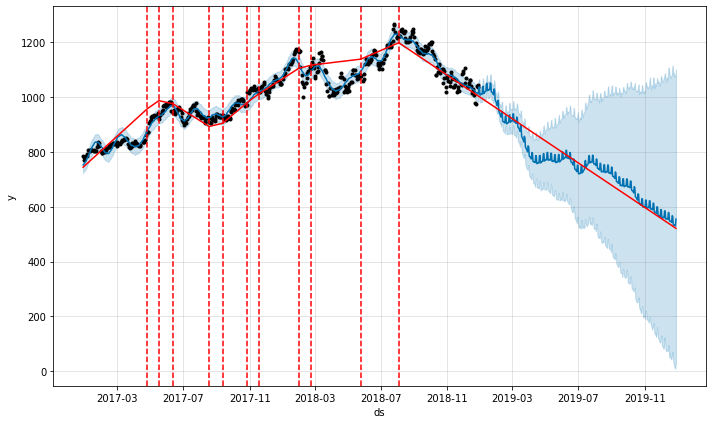

In [10]:
m=Prophet()
m.fit(goog.iloc[-252*2:])
future=m.make_future_dataframe(periods=365)
forecast=m.predict(future)
fig=m.plot(forecast);
a=add_changepoints_to_plot(fig.gca(),m,forecast)

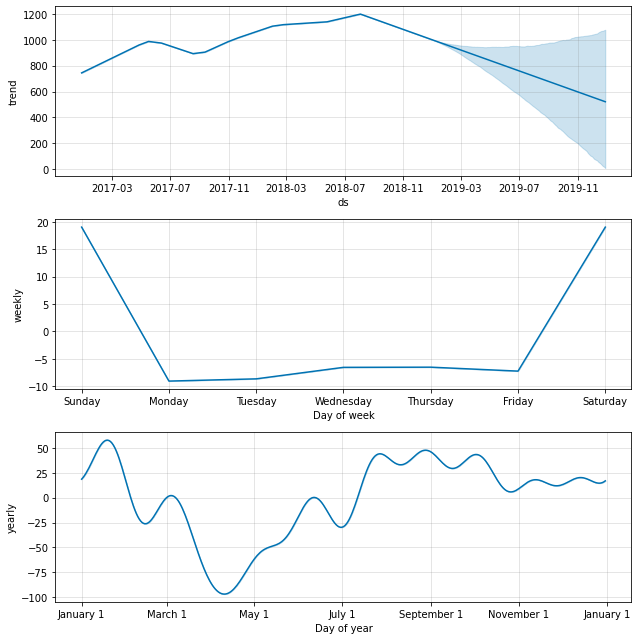

In [11]:
m.plot_components(forecast);

15:49:49 - cmdstanpy - INFO - Chain [1] start processing
15:49:50 - cmdstanpy - INFO - Chain [1] done processing


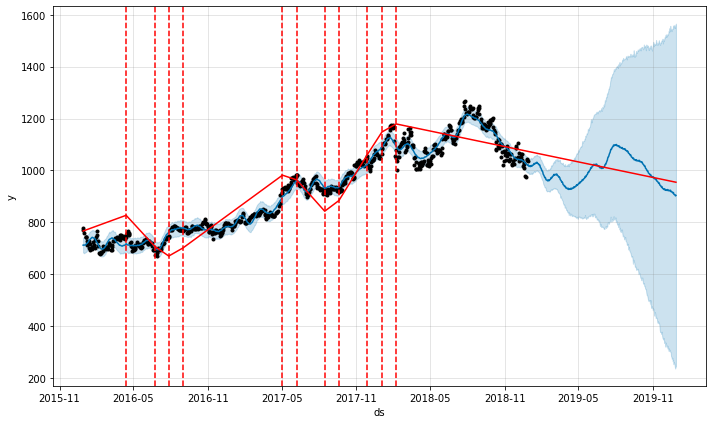

In [12]:
#BAD
m=Prophet(daily_seasonality=True)
m.fit(goog.iloc[-252*3:])
future=m.make_future_dataframe(periods=365)
forecast=m.predict(future)
fig=m.plot(forecast);
a=add_changepoints_to_plot(fig.gca(),m,forecast)

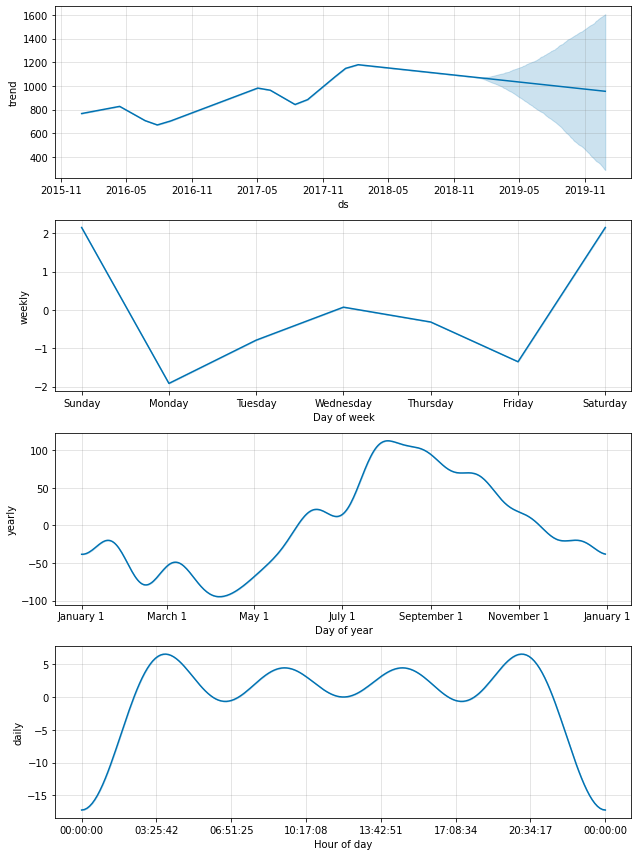

In [13]:
m.plot_components(forecast);

15:52:39 - cmdstanpy - INFO - Chain [1] start processing
15:52:40 - cmdstanpy - INFO - Chain [1] done processing


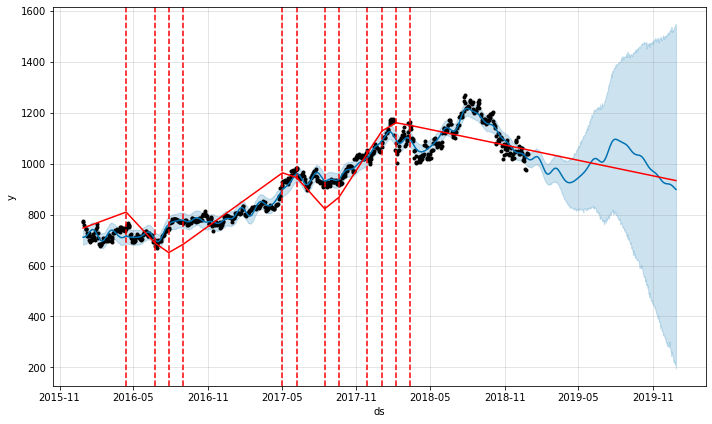

In [17]:
m=Prophet(weekly_seasonality=False)
m.fit(goog.iloc[-252*3:])
future=m.make_future_dataframe(periods=365)
forecast=m.predict(future)
fig=m.plot(forecast);
a=add_changepoints_to_plot(fig.gca(),m,forecast)

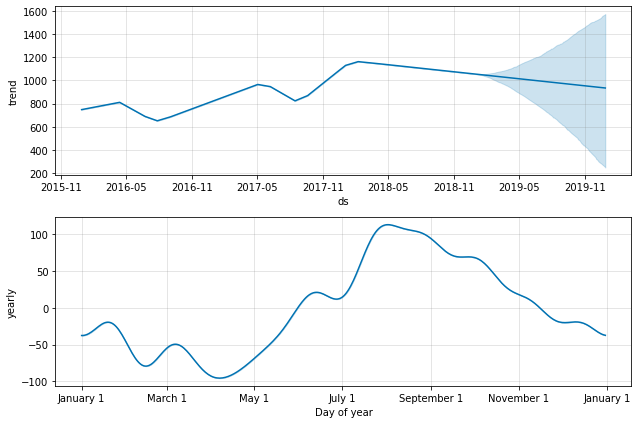

In [18]:
m.plot_components(forecast);

Cross Validation

In [19]:
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import plot_cross_validation_metric

In [20]:
m=Prophet(weekly_seasonality=False)

In [21]:
m.fit(goog[-252*2:])

15:55:18 - cmdstanpy - INFO - Chain [1] start processing
15:55:19 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
df_cv=cross_validation(
    m,
    initial='365 days',
    period='5 days',
    horizon='5 days'
)

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/73 [00:00<?, ?it/s]

15:56:49 - cmdstanpy - INFO - Chain [1] start processing
15:56:49 - cmdstanpy - INFO - Chain [1] done processing
15:56:52 - cmdstanpy - INFO - Chain [1] start processing
15:56:52 - cmdstanpy - INFO - Chain [1] done processing
15:56:54 - cmdstanpy - INFO - Chain [1] start processing
15:56:55 - cmdstanpy - INFO - Chain [1] done processing
15:56:57 - cmdstanpy - INFO - Chain [1] start processing
15:56:58 - cmdstanpy - INFO - Chain [1] done processing
15:57:00 - cmdstanpy - INFO - Chain [1] start processing
15:57:01 - cmdstanpy - INFO - Chain [1] done processing
15:57:03 - cmdstanpy - INFO - Chain [1] start processing
15:57:03 - cmdstanpy - INFO - Chain [1] done processing
15:57:05 - cmdstanpy - INFO - Chain [1] start processing
15:57:06 - cmdstanpy - INFO - Chain [1] done processing
15:57:08 - cmdstanpy - INFO - Chain [1] start processing
15:57:09 - cmdstanpy - INFO - Chain [1] done processing
15:57:12 - cmdstanpy - INFO - Chain [1] start processing
15:57:12 - cmdstanpy - INFO - Chain [1]

In [23]:
df_cv.head(20)

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2017-12-29,1065.708769,1051.814723,1080.262947,1046.400024,2017-12-28
1,2018-01-02,1069.714379,1056.413192,1083.499995,1065.000000,2017-12-28
2,2018-01-03,1065.833806,1051.436929,1078.583646,1082.479980,2018-01-02
3,2018-01-04,1066.915990,1053.112994,1080.697702,1086.400024,2018-01-02
4,2018-01-05,1068.098641,1053.743588,1081.314710,1102.229980,2018-01-02
5,2018-01-08,1086.325255,1072.381574,1101.015308,1106.939941,2018-01-07
6,2018-01-09,1088.142336,1074.230401,1102.770565,1106.260010,2018-01-07
7,2018-01-10,1089.929374,1075.605591,1103.901064,1102.609985,2018-01-07
8,2018-01-11,1091.666835,1079.163771,1106.862821,1105.520020,2018-01-07
9,2018-01-12,1093.334630,1079.572696,1107.263437,1122.260010,2018-01-07


In [24]:
df_cv.shape

(251, 6)

In [27]:
naive=df_cv[['ds','yhat','y','cutoff']].copy()

In [29]:
naive_storage=np.zeros(naive.shape[0])
one_day=pd.Timedelta(1,'day')
for i,row in naive.iterrows():
    cutoff=row['cutoff']
    while cutoff not in goog.index:
        cutoff=cutoff-one_day
    naive_storage[i]=goog.loc[cutoff]['y']
naive['yhat']=naive_storage

In [31]:
pm=performance_metrics(df_cv)
pm['smape'].mean()

0.031195761382078913

In [32]:
naive_metrics=performance_metrics(naive)
naive_metrics['smape'].mean()

0.020548255026446992

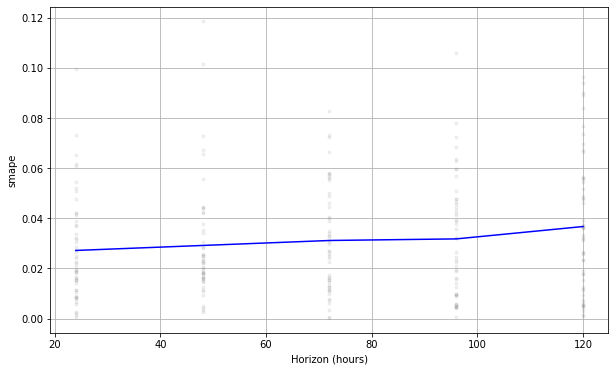

In [33]:
plot_cross_validation_metric(df_cv,metric='smape');

Cross Validation with logged Data

In [34]:
log_goog=goog.copy()
log_goog['y']=np.log(goog['y'])

In [35]:
m=Prophet(weekly_seasonality=False)
m.fit(log_goog[-252*2:])
df_cv=cross_validation(
    m,
    initial='365 days',
    period='30 days',
    horizon='60 days'
)
pm=performance_metrics(df_cv)
pm['smape'].mean()

16:12:51 - cmdstanpy - INFO - Chain [1] start processing
16:12:52 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/11 [00:00<?, ?it/s]

16:12:53 - cmdstanpy - INFO - Chain [1] start processing
16:12:53 - cmdstanpy - INFO - Chain [1] done processing
16:12:56 - cmdstanpy - INFO - Chain [1] start processing
16:12:57 - cmdstanpy - INFO - Chain [1] done processing
16:12:59 - cmdstanpy - INFO - Chain [1] start processing
16:13:00 - cmdstanpy - INFO - Chain [1] done processing
16:13:03 - cmdstanpy - INFO - Chain [1] start processing
16:13:04 - cmdstanpy - INFO - Chain [1] done processing
16:13:06 - cmdstanpy - INFO - Chain [1] start processing
16:13:07 - cmdstanpy - INFO - Chain [1] done processing
16:13:09 - cmdstanpy - INFO - Chain [1] start processing
16:13:10 - cmdstanpy - INFO - Chain [1] done processing
16:13:12 - cmdstanpy - INFO - Chain [1] start processing
16:13:13 - cmdstanpy - INFO - Chain [1] done processing
16:13:15 - cmdstanpy - INFO - Chain [1] start processing
16:13:16 - cmdstanpy - INFO - Chain [1] done processing
16:13:18 - cmdstanpy - INFO - Chain [1] start processing
16:13:19 - cmdstanpy - INFO - Chain [1]

0.014597757943247852

In [37]:
naive=df_cv[['ds','yhat','y','cutoff']].copy()
naive_storage=np.zeros(naive.shape[0])
#one_day=pd.Timedelta(1,'day')
for i,row in naive.iterrows():
    cutoff=row['cutoff']
    while cutoff not in goog.index:
        cutoff=cutoff-pd.Timedelta(1,'day')
    naive_storage[i]=goog.loc[cutoff]['y']
naive['yhat']=naive_storage
naive_metrics=performance_metrics(naive)
naive_metrics['smape'].mean()

1.974844703738177

In [ ]:
plot_cross_validation_metric(df_cv,metric='smape');